# TensorFlow Course 1 Week 2 - Complete Computer Vision Practice Notebook

## Introduction to Computer Vision

This comprehensive notebook covers all concepts from Week 2 of the TensorFlow specialization, focusing on computer vision with the Fashion MNIST dataset. We'll build neural networks to classify clothing items and explore various techniques for optimization.



## Environment Setup



In [1]:
%pip install pydot

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

print(f"TensorFlow version: {tf.__version__}")
print("Environment ready for computer vision!")


TensorFlow version: 2.20.0
Environment ready for computer vision!


## Understanding the Fashion MNIST Dataset

The Fashion MNIST dataset contains **70,000 grayscale images** of clothing items across **10 categories**. Each image is **28×28 pixels** with pixel values ranging from **0-255**.

**Dataset Structure:**

-   **Training set**: 60,000 images for learning patterns
-   **Test set**: 10,000 images for evaluating performance
-   **Image dimensions**: 28×28 pixels (784 total pixels per image)
-   **Color format**: Grayscale (single channel)
-   **Labels**: Numeric (0-9) for language neutrality

**Label Mapping:**

1. T-shirt/top  
2. Trouser  
3. Pullover  
4. Dress  
5. Coat  
6. Sandal  
7. Shirt  
8. Sneaker  
9. Bag  
10. Ankle boot  


In [3]:
# Load the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Define class names for better visualization
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Dataset loaded successfully!")
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Pixel value range: {train_images.min()} to {train_images.max()}")

Dataset loaded successfully!
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Pixel value range: 0 to 255


### Validation Data Source

When you see `validation_data=(test_images, test_labels)` in the training code, this is **technically incorrect** for a real machine learning workflow. Here's what's actually happening:

**What the code is doing:**

-   Training on: 60,000 training images
-   "Validating" on: 10,000 test images **during training**

**Why this is problematic:** The test set should remain completely unseen until final evaluation. Using test data for validation during training can lead to "data leakage" - the model indirectly learns about the test set.

### Correct Approach: Train/Validation/Test Split

In practice, you should split your data three ways:

```python
# Correct approach
total_train = 60,000
train_size = 48,000      # 80% for training  
validation_size = 12,000 # 20% for validation
test_size = 10,000       # Separate test set

# Split training data
train_images_final = train_images[:48000]
train_labels_final = train_labels[:48000]

val_images = train_images[48000:]  # From original training set
val_labels = train_labels[48000:]  # From original training set

# Test set remains untouched until final evaluation
test_images = test_images  # Only used at the very end
test_labels = test_labels  # Only used at the very end

```


### What Each Set Does

**Training Set (48,000):** Model learns from this data **Validation Set (12,000):** Used during training to:

-   Monitor performance on unseen data
-   Trigger early stopping
-   Tune hyperparameters
-   Select best model

**Test Set (10,000):** Used only once at the very end for final performance evaluation

### Why the Course Uses Test Data for Validation

The Fashion MNIST tutorial uses the test set for validation because:

1.  It's simpler for educational purposes
2.  Fashion MNIST is a well-established benchmark
3.  The focus is on learning basic concepts, not perfect ML practices

In real projects, you should always create a proper train/validation/test split from your data.

## Data Exploration and Visualization

Understanding your data is crucial before building models. Let's explore the structure and characteristics of our dataset.

**Key concepts:**

-   **Data inspection**: Always examine your data before training
-   **Pixel analysis**: Understanding how images are represented as numbers
-   **Label distribution**: Checking if dataset is balanced across categories


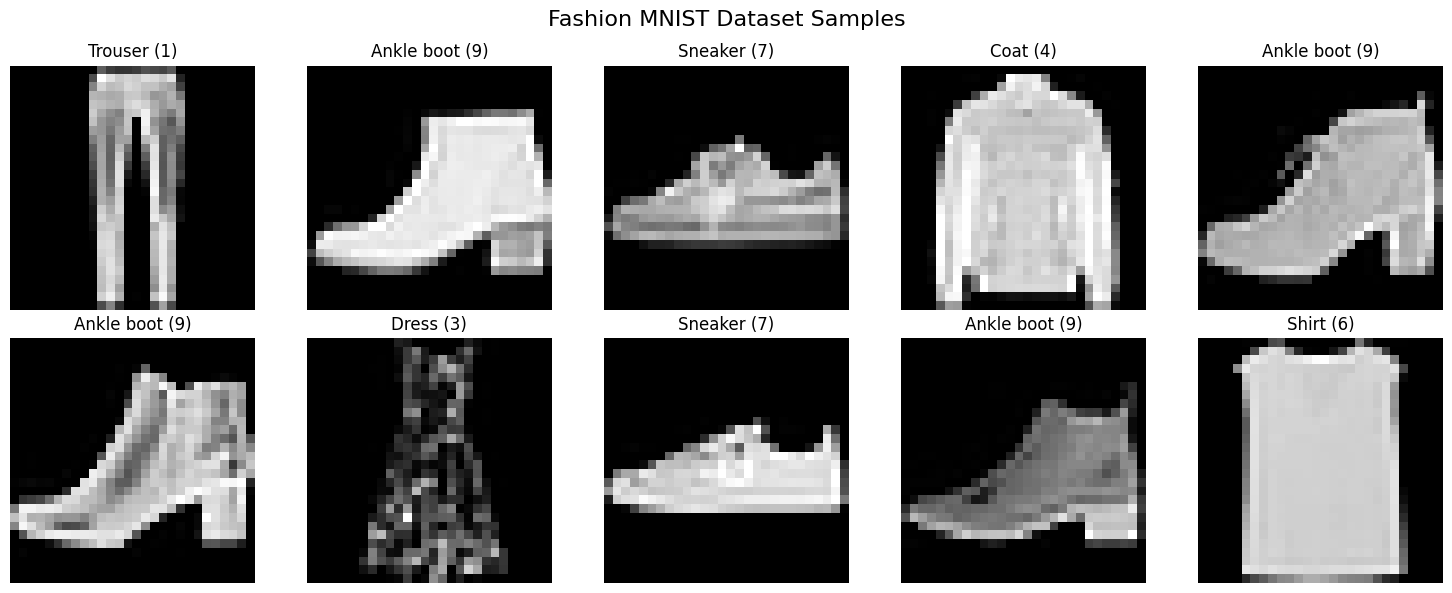


Dataset Statistics:
--------------------------------------------------
T-shirt/top: 6000 images (10.0%)
Trouser: 6000 images (10.0%)
Pullover: 6000 images (10.0%)
Dress: 6000 images (10.0%)
Coat: 6000 images (10.0%)
Sandal: 6000 images (10.0%)
Shirt: 6000 images (10.0%)
Sneaker: 6000 images (10.0%)
Bag: 6000 images (10.0%)
Ankle boot: 6000 images (10.0%)


In [4]:
def explore_dataset(images, labels, class_names, n_samples=10):
    """
    Explores and visualizes samples from the dataset.
    
    Args:
        images: Array of images
        labels: Array of corresponding labels
        class_names: List of class names
        n_samples: Number of samples to display
    """
    # Set up the plotting grid
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Fashion MNIST Dataset Samples', fontsize=16)
    
    # Display random samples
    for i in range(n_samples):
        row = i // 5
        col = i % 5
        
        # Select a random image
        idx = random.randint(0, len(images) - 1)
        
        # Plot the image
        axes[row, col].imshow(images[idx], cmap='gray')
        axes[row, col].set_title(f'{class_names[labels[idx]]} ({labels[idx]})')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Display dataset statistics
    print("\nDataset Statistics:")
    print("-" * 50)
    unique_labels, counts = np.unique(labels, return_counts=True)
    for label, count in zip(unique_labels, counts):
        print(f"{class_names[label]}: {count} images ({count/len(labels)*100:.1f}%)")

# Explore the training dataset
explore_dataset(train_images, train_labels, class_names)



## Detailed Image Analysis

Let's examine individual images to understand how computers "see" clothing items as arrays of numbers.

**Mathematical representation:**

-   Each image is a matrix $I \in \mathbb{R}^{28 \times 28}$
-   Pixel values: $I_{i,j} \in [0, 255]$ where $(i,j)$ are pixel coordinates
-   Total information per image: $28 \times 28 = 784$ numerical values



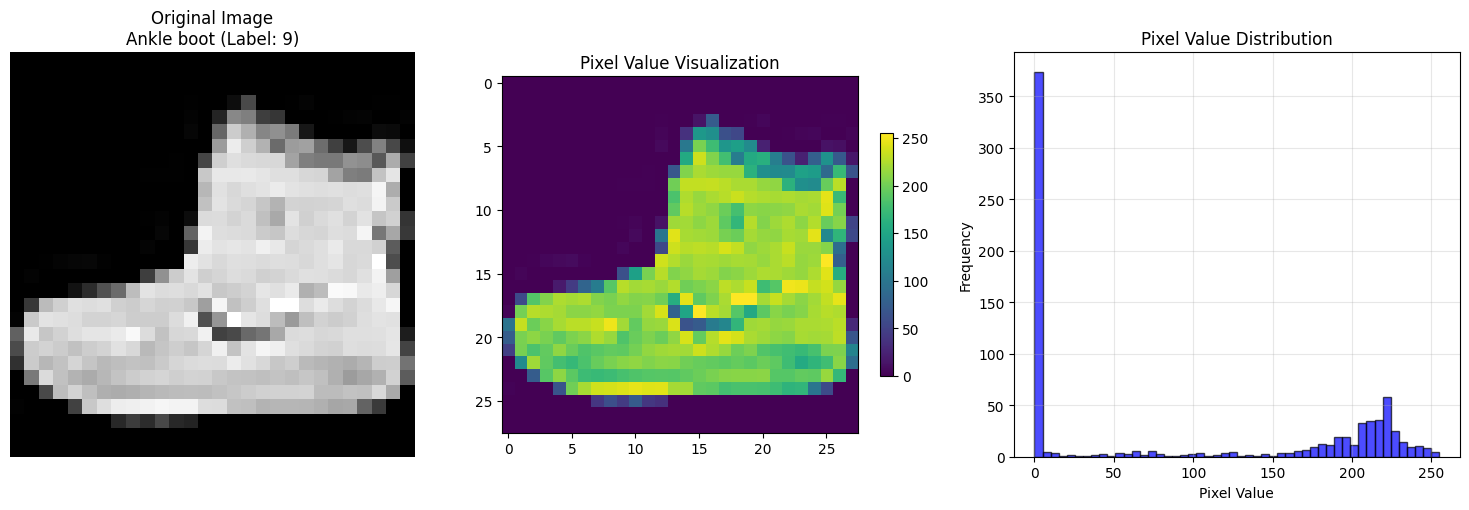


Image Analysis for Index 0:
Class: Ankle boot (Label: 9)
Image shape: (28, 28)
Data type: uint8
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 97.25
Standard deviation: 101.79

Sample pixel values (top-left 8x8 corner):
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


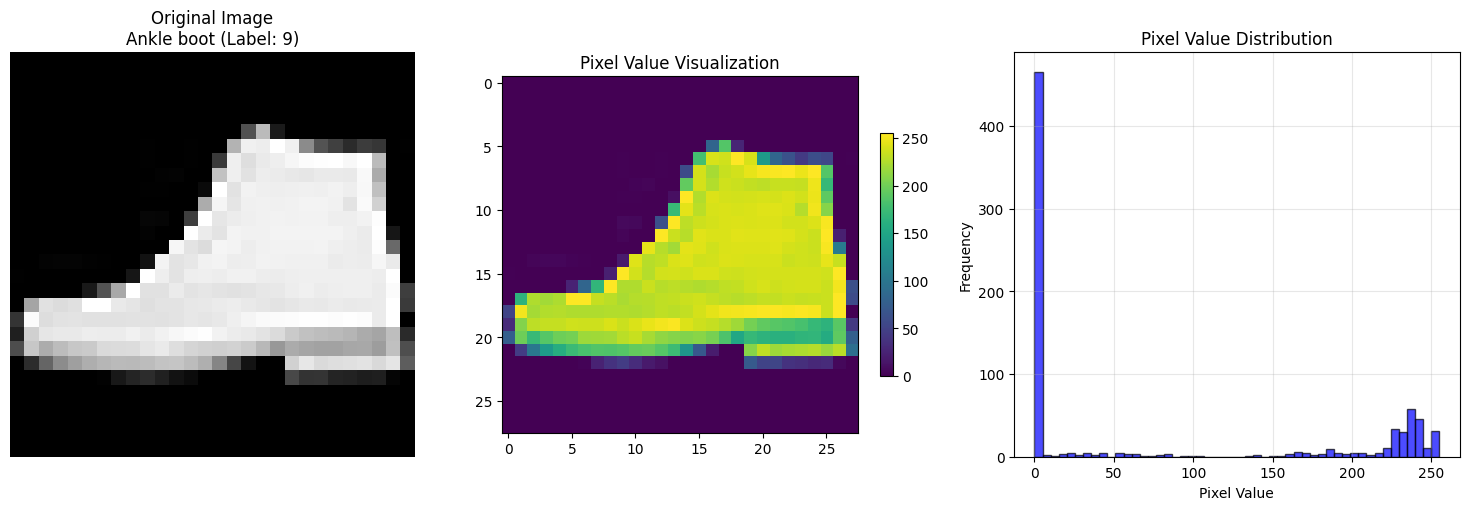


Image Analysis for Index 42:
Class: Ankle boot (Label: 9)
Image shape: (28, 28)
Data type: uint8
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 82.48
Standard deviation: 108.08

Sample pixel values (top-left 8x8 corner):
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


In [5]:
def analyze_single_image(images, labels, class_names, index=0):
    """
    Provides detailed analysis of a single image.
    
    Args:
        images: Array of images
        labels: Array of labels
        class_names: List of class names
        index: Index of image to analyze
    """
    # Get the specific image and label
    image = images[index]
    label = labels[index]
    
    # Create visualization
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    ax1.imshow(image, cmap='gray')
    ax1.set_title(f'Original Image\n{class_names[label]} (Label: {label})')
    ax1.axis('off')
    
    # Image with colorbar showing pixel values
    im = ax2.imshow(image, cmap='viridis')
    ax2.set_title('Pixel Value Visualization')
    plt.colorbar(im, ax=ax2, shrink=0.6)
    
    # Pixel value histogram
    ax3.hist(image.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax3.set_title('Pixel Value Distribution')
    ax3.set_xlabel('Pixel Value')
    ax3.set_ylabel('Frequency')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print(f"\nImage Analysis for Index {index}:")
    print(f"Class: {class_names[label]} (Label: {label})")
    print(f"Image shape: {image.shape}")
    print(f"Data type: {image.dtype}")
    print(f"Min pixel value: {image.min()}")
    print(f"Max pixel value: {image.max()}")
    print(f"Mean pixel value: {image.mean():.2f}")
    print(f"Standard deviation: {image.std():.2f}")
    
    # Display a portion of the raw pixel values
    print(f"\nSample pixel values (top-left 8x8 corner):")
    print(image[:8, :8])

# Analyze the first training image
analyze_single_image(train_images, train_labels, class_names, index=0)

# Analyze another image (try index 42 for an ankle boot)
analyze_single_image(train_images, train_labels, class_names, index=42)



## Data Preprocessing: Normalization

Neural networks perform better with normalized data. We'll convert pixel values from the range [0, 255] to [0, 1].

**Mathematical transformation:** 

$$
\text{normalized\_pixel} = \frac{\text{original\_pixel}}{255}
$$

**Why normalization helps:**

-   Prevents large pixel values from dominating the learning process
-   Ensures all input features have similar scales
-   Improves convergence speed and stability during training
-   Reduces the risk of numerical instability



Original pixel value range:
Training images: 0 to 255
Test images: 0 to 255

After normalization:
Training images: 0.000 to 1.000
Test images: 0.000 to 1.000


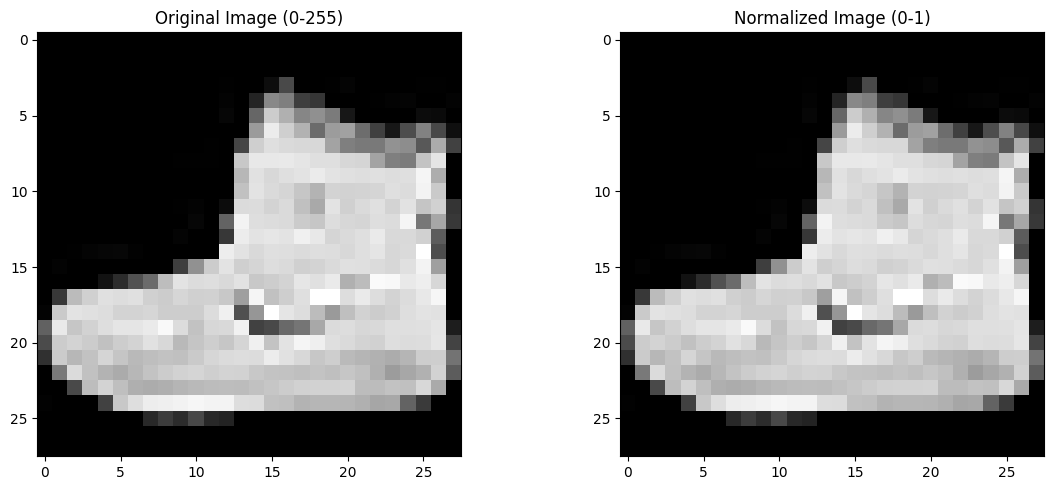

In [6]:
def normalize_images(train_images, test_images):
    """
    Normalizes image pixel values from [0, 255] to [0, 1].
    
    Args:
        train_images: Training image array
        test_images: Test image array
    
    Returns:
        Normalized training and test images
    """
    print("Original pixel value range:")
    print(f"Training images: {train_images.min()} to {train_images.max()}")
    print(f"Test images: {test_images.min()} to {test_images.max()}")
    
    # Normalize by dividing by 255.0
    train_images_norm = train_images.astype('float32') / 255.0
    test_images_norm = test_images.astype('float32') / 255.0
    
    print("\nAfter normalization:")
    print(f"Training images: {train_images_norm.min():.3f} to {train_images_norm.max():.3f}")
    print(f"Test images: {test_images_norm.min():.3f} to {test_images_norm.max():.3f}")
    
    return train_images_norm, test_images_norm

# Normalize the images
train_images_norm, test_images_norm = normalize_images(train_images, test_images)

# Verify normalization with a comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original image
ax1.imshow(train_images[0], cmap='gray')
ax1.set_title('Original Image (0-255)')

# Normalized image
ax2.imshow(train_images_norm[0], cmap='gray')
ax2.set_title('Normalized Image (0-1)')

plt.tight_layout()
plt.show()

## Understanding Activation Functions

Before building our model, let's understand the activation functions we'll use.

**ReLU (Rectified Linear Unit):** $$\text{ReLU}(x) = \max(0, x) = \begin{cases} x & \text{if } x > 0 \ 0 & \text{if } x \leq 0 \end{cases}$$

**Softmax Function:** $$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{K} e^{x_j}}$$

Where $K$ is the number of classes (10 in our case).



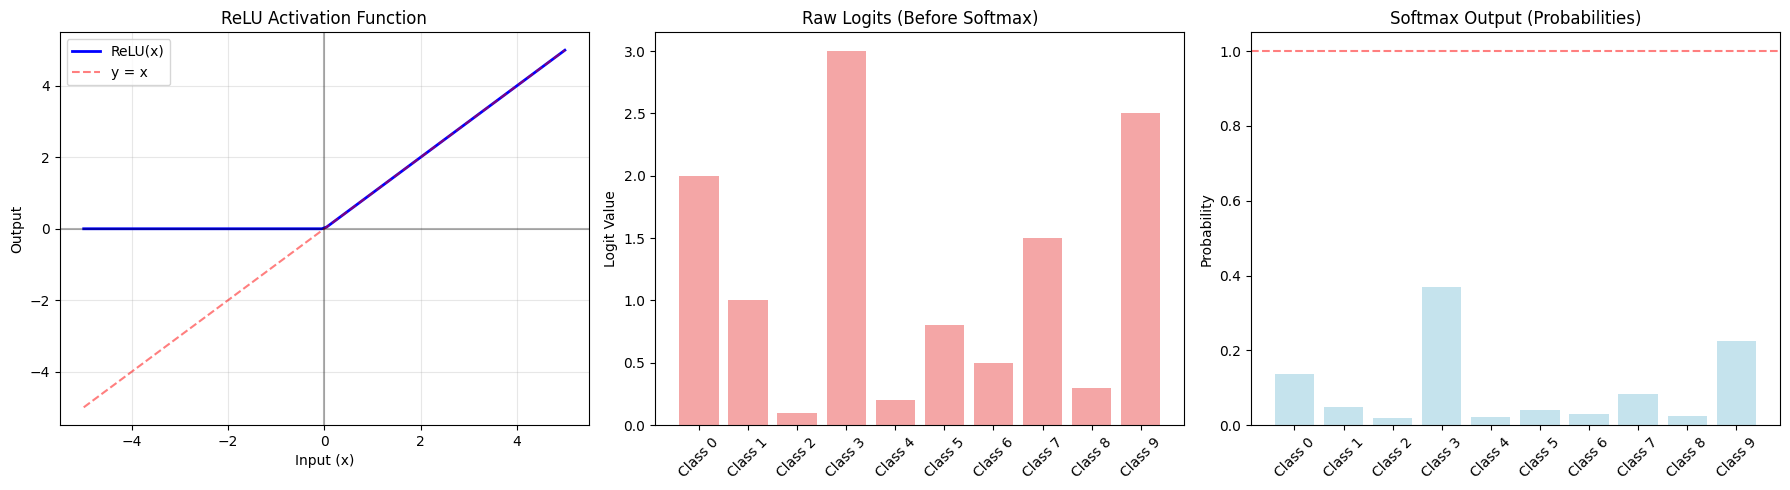

Softmax Demonstration:
Input logits: [2.  1.  0.1 3.  0.2 0.8 0.5 1.5 0.3 2.5]
Softmax probabilities: [0.13580888 0.0499613  0.02031275 0.36916682 0.02244906 0.04090485
 0.03030306 0.08237225 0.02481005 0.22391099]
Sum of probabilities: 1.000000
Predicted class: 3
Prediction confidence: 0.369


In [7]:
def demonstrate_activation_functions():
    """
    Demonstrates ReLU and Softmax activation functions.
    """
    # ReLU demonstration
    x_values = np.linspace(-5, 5, 100)
    relu_values = np.maximum(0, x_values)  # ReLU function
    
    # Create sample logits for softmax
    sample_logits = np.array([[2.0, 1.0, 0.1, 3.0, 0.2, 0.8, 0.5, 1.5, 0.3, 2.5]])
    
    # Apply softmax
    softmax_output = tf.nn.softmax(sample_logits)
    
    # Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # ReLU plot
    ax1.plot(x_values, relu_values, 'b-', linewidth=2, label='ReLU(x)')
    ax1.plot(x_values, x_values, 'r--', alpha=0.5, label='y = x')
    ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax1.set_xlabel('Input (x)')
    ax1.set_ylabel('Output')
    ax1.set_title('ReLU Activation Function')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Softmax input (logits)
    classes = [f'Class {i}' for i in range(10)]
    ax2.bar(classes, sample_logits[0], color='lightcoral', alpha=0.7)
    ax2.set_title('Raw Logits (Before Softmax)')
    ax2.set_ylabel('Logit Value')
    ax2.tick_params(axis='x', rotation=45)
    
    # Softmax output (probabilities)
    ax3.bar(classes, softmax_output[0], color='lightblue', alpha=0.7)
    ax3.set_title('Softmax Output (Probabilities)')
    ax3.set_ylabel('Probability')
    ax3.tick_params(axis='x', rotation=45)
    ax3.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Sum = 1.0')
    
    plt.tight_layout()
    plt.show()
    
    # Print numerical results
    print("Softmax Demonstration:")
    print(f"Input logits: {sample_logits[0]}")
    print(f"Softmax probabilities: {softmax_output[0].numpy()}")
    print(f"Sum of probabilities: {np.sum(softmax_output[0].numpy()):.6f}")
    print(f"Predicted class: {np.argmax(softmax_output[0])}")
    print(f"Prediction confidence: {np.max(softmax_output[0]):.3f}")

demonstrate_activation_functions()



## Building the Basic Neural Network

Let's build our first computer vision neural network using the concepts we've learned.

**Network Architecture:** $$\text{Input}(28 \times 28) \rightarrow \text{Flatten}(784) \rightarrow \text{Dense}(128) \rightarrow \text{Dense}(10)$$

**Mathematical flow:**

1.  **Flatten**: $\mathbf{x} \in \mathbb{R}^{28 \times 28} \rightarrow \mathbf{x}' \in \mathbb{R}^{784}$
2.  **Hidden layer**: $\mathbf{h} = \text{ReLU}(\mathbf{W_1} \mathbf{x}' + \mathbf{b_1})$ where $\mathbf{W_1} \in \mathbb{R}^{128 \times 784}$
3.  **Output layer**: $\mathbf{y} = \text{Softmax}(\mathbf{W_2} \mathbf{h} + \mathbf{b_2})$ where $\mathbf{W_2} \in \mathbb{R}^{10 \times 128}$


In [8]:
def create_basic_model():
    """
    Creates a basic neural network for Fashion MNIST classification.
    
    Returns:
        Compiled TensorFlow model
    """
    model = tf.keras.Sequential([
        # Input layer: defines the expected input shape
        tf.keras.Input(shape=(28, 28)),
        
        # Flatten layer: converts 28x28 matrix to 784-length vector
        tf.keras.layers.Flatten(),
        
        # Hidden layer: 128 neurons with ReLU activation
        tf.keras.layers.Dense(128, activation='relu', name='hidden_layer'),
        
        # Output layer: 10 neurons (one per class) with softmax
        tf.keras.layers.Dense(10, activation='softmax', name='output_layer')
    ])
    
    # Compile the model
    model.compile(
        optimizer='adam',  # Adam optimizer for efficient training
        loss='sparse_categorical_crossentropy',  # Loss for multi-class classification
        metrics=['accuracy']  # Track accuracy during training
    )
    
    return model

# Create and display the model
basic_model = create_basic_model()

# Display model architecture
print("Model Architecture:")
basic_model.summary()

# Visualize the model structure
tf.keras.utils.plot_model(
    basic_model, 
    show_shapes=True, 
    show_layer_names=True,
    rankdir='TB'
)


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer (Dense)            │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## Training the Basic Model

Now let's train our model and monitor its performance.

**Training process:**

1.  **Forward pass**: Compute predictions
2.  **Loss calculation**: Measure prediction errors
3.  **Backward pass**: Compute gradients
4.  **Parameter update**: Adjust weights using optimizer



In [9]:
def train_basic_model(model, train_images, train_labels, test_images, test_labels, epochs=5):
    """
    Trains the basic model and displays training progress.
    
    Args:
        model: The neural network model
        train_images, train_labels: Training data
        test_images, test_labels: Test data for validation
        epochs: Number of training epochs
    
    Returns:
        Training history
    """
    print("Starting training...")
    print("=" * 50)
    
    # Train the model
    history = model.fit(
        train_images, train_labels,
        epochs=epochs,
        validation_data=(test_images, test_labels),
        verbose=1  # Show progress
    )
    
    # Evaluate final performance
    print("\nFinal Evaluation:")
    print("=" * 50)
    train_loss, train_acc = model.evaluate(train_images, train_labels, verbose=0)
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    
    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Test loss: {test_loss:.4f}")
    
    return history

# Train the basic model
training_history = train_basic_model(
    basic_model, 
    train_images_norm, train_labels,
    test_images_norm, test_labels,
    epochs=5
)

Starting training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8239 - loss: 0.5015 - val_accuracy: 0.8416 - val_loss: 0.4410
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 801us/step - accuracy: 0.8639 - loss: 0.3773 - val_accuracy: 0.8540 - val_loss: 0.4091
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step - accuracy: 0.8780 - loss: 0.3403 - val_accuracy: 0.8698 - val_loss: 0.3727
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 848us/step - accuracy: 0.8842 - loss: 0.3136 - val_accuracy: 0.8688 - val_loss: 0.3628
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - accuracy: 0.8904 - loss: 0.2969 - val_accuracy: 0.8739 - val_loss: 0.3489

Final Evaluation:
Training accuracy: 0.8960
Test accuracy: 0.8739
Training loss: 0.2824
Test loss: 0.3489


## Visualizing Training Progress

Understanding how your model learns over time is crucial for optimization.


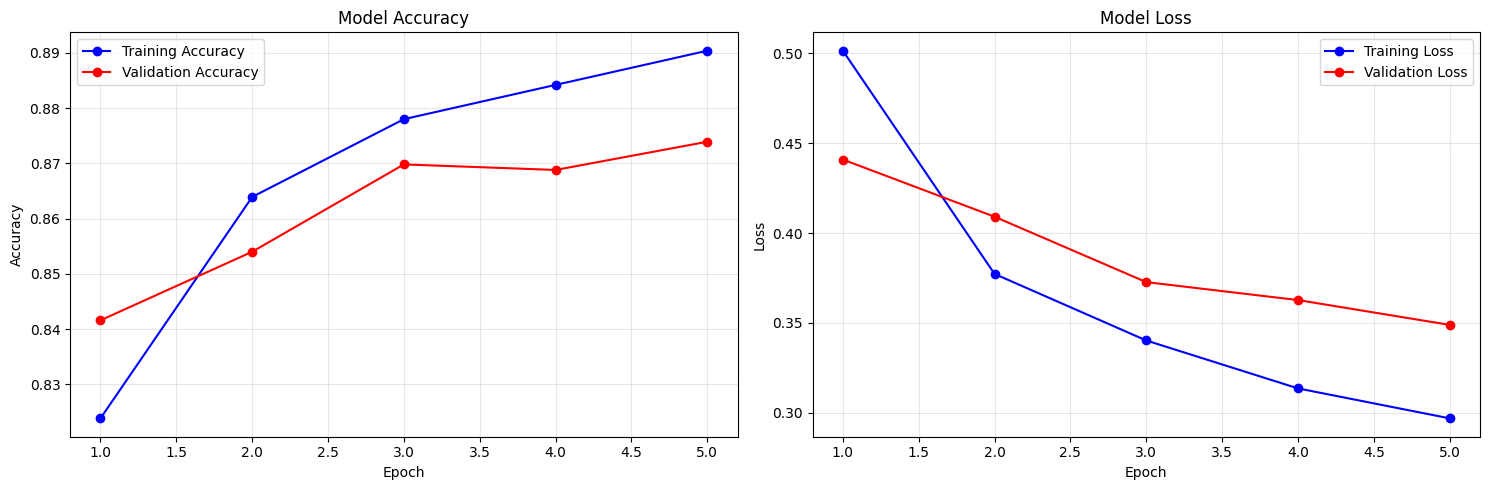


Training Insights:
Final training accuracy: 0.8904
Final validation accuracy: 0.8739
Accuracy gap: 0.0165
✅ Good generalization - small accuracy gap


In [10]:
def plot_training_history(history):
    """
    Plots training and validation metrics over epochs.
    
    Args:
        history: Training history from model.fit()
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs_range = range(1, len(history.history['loss']) + 1)
    
    # Plot training & validation accuracy
    ax1.plot(epochs_range, history.history['accuracy'], 'b-o', label='Training Accuracy')
    ax1.plot(epochs_range, history.history['val_accuracy'], 'r-o', label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot training & validation loss
    ax2.plot(epochs_range, history.history['loss'], 'b-o', label='Training Loss')
    ax2.plot(epochs_range, history.history['val_loss'], 'r-o', label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    accuracy_gap = final_train_acc - final_val_acc
    
    print(f"\nTraining Insights:")
    print(f"Final training accuracy: {final_train_acc:.4f}")
    print(f"Final validation accuracy: {final_val_acc:.4f}")
    print(f"Accuracy gap: {accuracy_gap:.4f}")
    
    if accuracy_gap > 0.05:
        print("⚠️  Large accuracy gap suggests possible overfitting")
    else:
        print("✅ Good generalization - small accuracy gap")

# Plot the training history
plot_training_history(training_history)



## Making Predictions and Understanding Output

Let's see how our trained model makes predictions on new images.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


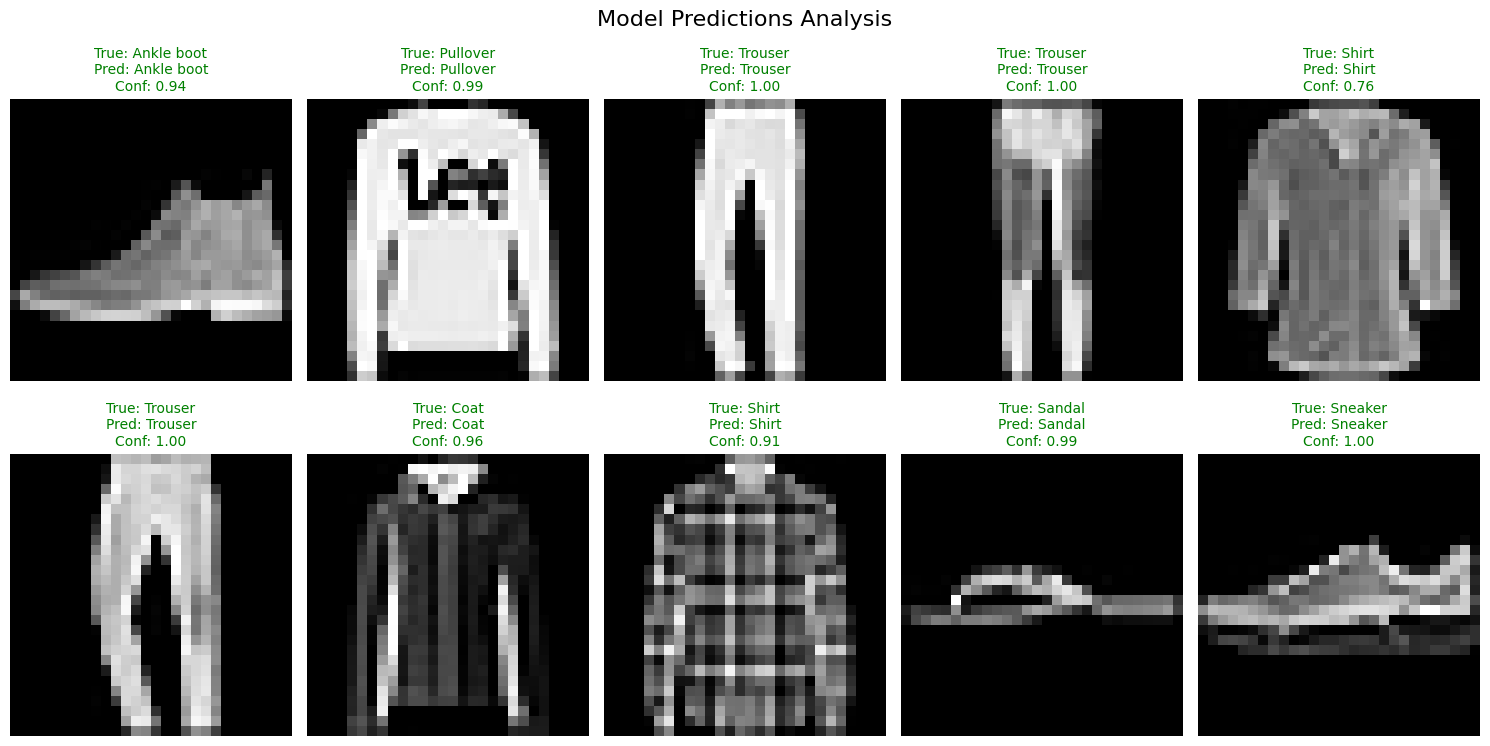

Detailed Analysis of First Prediction:
True label: 9 (Ankle boot)
Predicted label: 9 (Ankle boot)
Prediction confidence: 0.9434

All class probabilities:
0: T-shirt/top  - 0.0000
1: Trouser      - 0.0000
2: Pullover     - 0.0000
3: Dress        - 0.0000
4: Coat         - 0.0000
5: Sandal       - 0.0161
6: Shirt        - 0.0000
7: Sneaker      - 0.0404
8: Bag          - 0.0001
9: Ankle boot   - 0.9434

Probabilities sum to: 1.000000


In [11]:
def analyze_predictions(model, images, labels, class_names, n_predictions=10):
    """
    Analyzes model predictions and displays results.
    
    Args:
        model: Trained model
        images: Test images
        labels: True labels
        class_names: List of class names
        n_predictions: Number of predictions to analyze
    """
    # Make predictions
    predictions = model.predict(images[:n_predictions])
    
    # Set up visualization
    fig, axes = plt.subplots(2, 5, figsize=(15, 8))
    fig.suptitle('Model Predictions Analysis', fontsize=16)
    
    for i in range(n_predictions):
        row = i // 5
        col = i % 5
        
        # Get prediction details
        predicted_class = np.argmax(predictions[i])
        confidence = predictions[i][predicted_class]
        true_class = labels[i]
        
        # Plot image
        axes[row, col].imshow(images[i], cmap='gray')
        
        # Color code: green for correct, red for incorrect
        color = 'green' if predicted_class == true_class else 'red'
        
        # Set title with prediction info
        axes[row, col].set_title(
            f'True: {class_names[true_class]}\n'
            f'Pred: {class_names[predicted_class]}\n'
            f'Conf: {confidence:.2f}',
            color=color, fontsize=10
        )
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Detailed analysis of first prediction
    print("Detailed Analysis of First Prediction:")
    print("=" * 50)
    print(f"True label: {labels[0]} ({class_names[labels[0]]})")
    print(f"Predicted label: {np.argmax(predictions[0])} ({class_names[np.argmax(predictions[0])]})")
    print(f"Prediction confidence: {predictions[0][np.argmax(predictions[0])]:.4f}")
    
    print("\nAll class probabilities:")
    for i, (class_name, prob) in enumerate(zip(class_names, predictions[0])):
        print(f"{i}: {class_name:12} - {prob:.4f}")
    
    print(f"\nProbabilities sum to: {np.sum(predictions[0]):.6f}")

# Analyze predictions
analyze_predictions(basic_model, test_images_norm, test_labels, class_names)



## Implementing Callbacks for Smart Training

Let's implement callbacks to automatically stop training when we reach desired performance.

**Callback functionality:**

-   Monitor training metrics after each epoch
-   Stop training early when conditions are met
-   Prevent overfitting and save computational resources



Training with callbacks:
🎯 Target: 88% validation accuracy
⏰ Early stopping: 3 epochs patience on validation loss
Epoch 1/20
1854/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - accuracy: 0.7777 - loss: 0.6429Epoch 1: accuracy = 0.8334, best = 0.8334, patience = 0/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 872us/step - accuracy: 0.8232 - loss: 0.5067 - val_accuracy: 0.8334 - val_loss: 0.4977
Epoch 2/20
1860/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - accuracy: 0.8597 - loss: 0.3887Epoch 2: accuracy = 0.8627, best = 0.8627, patience = 0/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 928us/step - accuracy: 0.8629 - loss: 0.3787 - val_accuracy: 0.8627 - val_loss: 0.3899
Epoch 3/20
1838/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.8765 - loss: 0.3441Epoch 3: accuracy = 0.8619, best = 0.8627, patience = 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 792us/step - accuracy: 0.8769 - loss: 0.3384 - val_accuracy: 0.8619 - val_loss: 0.3795
Epoch 4/20
1798/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - accuracy: 0.8832 - loss:

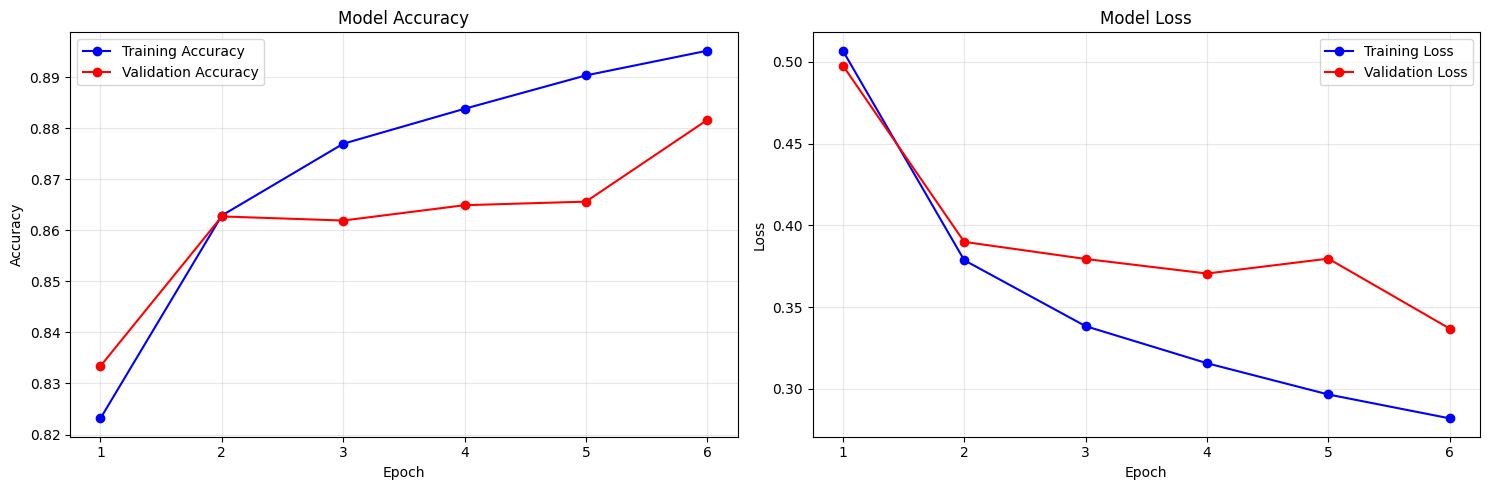


Training Insights:
Final training accuracy: 0.8952
Final validation accuracy: 0.8816
Accuracy gap: 0.0135
✅ Good generalization - small accuracy gap


In [12]:
class PerformanceCallback(tf.keras.callbacks.Callback):
    """
    Custom callback to stop training based on performance criteria.
    """
    
    def __init__(self, target_accuracy=0.85, patience=3, monitor_val=True):
        """
        Initialize the callback.
        
        Args:
            target_accuracy: Accuracy threshold to stop training
            patience: Number of epochs to wait for improvement
            monitor_val: Whether to monitor validation or training accuracy
        """
        super().__init__()
        self.target_accuracy = target_accuracy
        self.patience = patience
        self.monitor_val = monitor_val
        self.wait = 0
        self.best_accuracy = 0
        
    def on_epoch_end(self, epoch, logs=None):
        """
        Called at the end of each epoch.
        """
        logs = logs or {}
        
        # Choose which accuracy to monitor
        current_accuracy = logs.get('val_accuracy' if self.monitor_val else 'accuracy', 0)
        
        # Check if target accuracy reached
        if current_accuracy >= self.target_accuracy:
            print(f"\n🎯 Target accuracy of {self.target_accuracy:.2f} reached!")
            print(f"Stopping training at epoch {epoch + 1}")
            self.model.stop_training = True
            return
        
        # Check for improvement (early stopping logic)
        if current_accuracy > self.best_accuracy:
            self.best_accuracy = current_accuracy
            self.wait = 0
        else:
            self.wait += 1
            
        print(f"Epoch {epoch + 1}: accuracy = {current_accuracy:.4f}, "
              f"best = {self.best_accuracy:.4f}, patience = {self.wait}/{self.patience}")

def train_with_callbacks():
    """
    Demonstrates training with custom callbacks.
    """
    # Create a new model for this demonstration
    callback_model = create_basic_model()
    
    # Create callback instances
    performance_callback = PerformanceCallback(
        target_accuracy=0.88,
        patience=2,
        monitor_val=True
    )
    
    # Built-in callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    
    # Train with callbacks
    print("Training with callbacks:")
    print("🎯 Target: 88% validation accuracy")
    print("⏰ Early stopping: 3 epochs patience on validation loss")
    print("=" * 60)
    
    history = callback_model.fit(
        train_images_norm, train_labels,
        epochs=20,  # Set high, let callbacks decide when to stop
        validation_data=(test_images_norm, test_labels),
        callbacks=[performance_callback, early_stopping],
        verbose=1
    )
    
    return callback_model, history

# Train with callbacks
callback_model, callback_history = train_with_callbacks()
plot_training_history(callback_history)



## Architecture Experimentation

Let's explore how different architectures affect performance.



Comparing Different Architectures

Training small model...
✅ Small model completed
   Parameters: 50,890
   Train accuracy: 0.8931
   Test accuracy: 0.8707

Training large model...
✅ Large model completed
   Parameters: 407,050
   Train accuracy: 0.9061
   Test accuracy: 0.8798

Training deep model...
✅ Deep model completed
   Parameters: 111,146
   Train accuracy: 0.8971
   Test accuracy: 0.8761

Training dropout model...
✅ Dropout model completed
   Parameters: 109,386
   Train accuracy: 0.8913
   Test accuracy: 0.8722


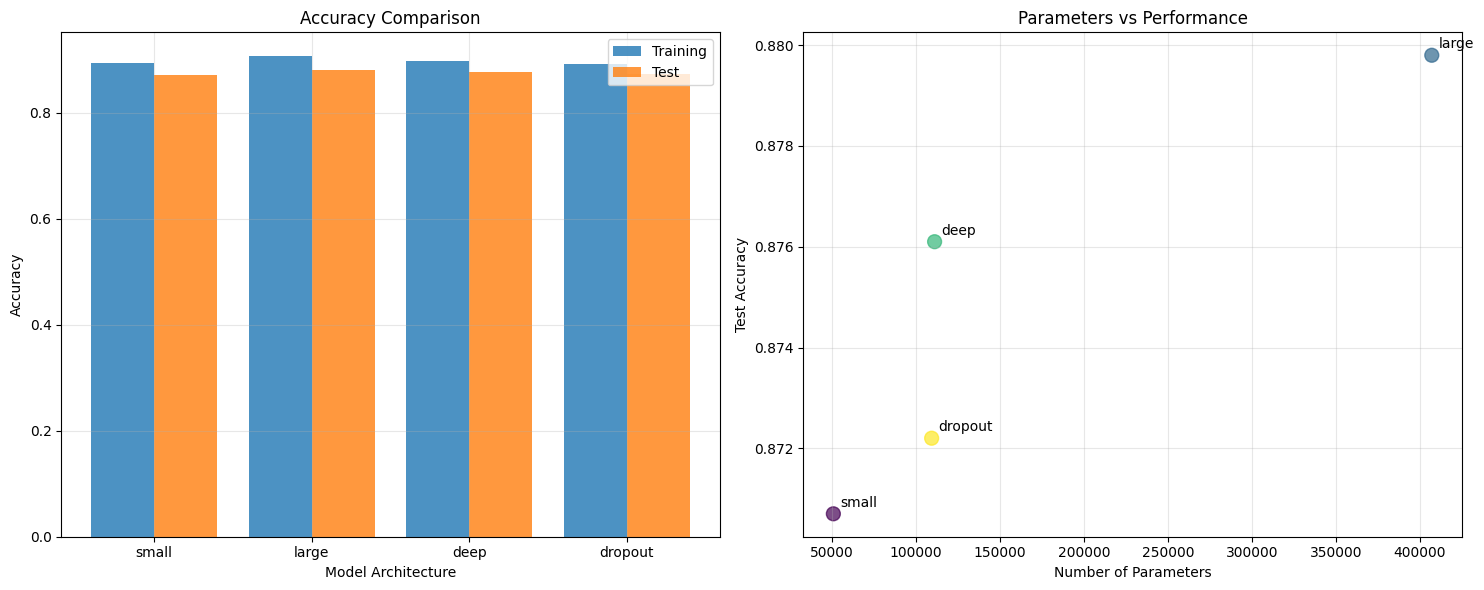


Detailed Architecture Comparison:

SMALL MODEL:
 Parameters: 50,890
 Training accuracy: 0.8931
 Test accuracy: 0.8707
 Overfitting gap: 0.0224

LARGE MODEL:
 Parameters: 407,050
 Training accuracy: 0.9061
 Test accuracy: 0.8798
 Overfitting gap: 0.0263

DEEP MODEL:
 Parameters: 111,146
 Training accuracy: 0.8971
 Test accuracy: 0.8761
 Overfitting gap: 0.0210

DROPOUT MODEL:
 Parameters: 109,386
 Training accuracy: 0.8913
 Test accuracy: 0.8722
 Overfitting gap: 0.0191


In [14]:
def create_experimental_models():
    """
    Creates different model architectures for comparison.
    
    Returns:
        Dictionary of models with different configurations
    """
    models = {}
    
    # Model 1: Fewer neurons
    models['small'] = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    # Model 2: More neurons
    models['large'] = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    # Model 3: Multiple hidden layers
    models['deep'] = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    # Model 4: With dropout for regularization
    models['dropout'] = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),  # 20% dropout
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.1),  # 10% dropout
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    # Compile all models
    for name, model in models.items():
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    
    return models

def compare_architectures(models, train_images, train_labels, test_images, test_labels):
    """
    Compares different model architectures.
    """
    results = {}
    
    print("Comparing Different Architectures")
    print("=" * 50)
    
    for name, model in models.items():
        print(f"\nTraining {name} model...")
        
        # Train model
        history = model.fit(
            train_images, train_labels,
            epochs=5,
            validation_data=(test_images, test_labels),
            verbose=0  # Silent training
        )
        
        # Evaluate
        train_loss, train_acc = model.evaluate(train_images, train_labels, verbose=0)
        test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
        
        # Store results
        results[name] = {
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'parameters': model.count_params(),
            'history': history
        }
        
        print(f"✅ {name.capitalize()} model completed")
        print(f"   Parameters: {model.count_params():,}")
        print(f"   Train accuracy: {train_acc:.4f}")
        print(f"   Test accuracy: {test_acc:.4f}")
    
    return results

# Create and compare models
experimental_models = create_experimental_models()
architecture_results = compare_architectures(
    experimental_models,
    train_images_norm, train_labels,
    test_images_norm, test_labels
)

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

model_names = list(architecture_results.keys())
train_accuracies = [results['train_accuracy'] for results in architecture_results.values()]
test_accuracies = [results['test_accuracy'] for results in architecture_results.values()]
parameters = [results['parameters'] for results in architecture_results.values()]

# Accuracy comparison
x_pos = np.arange(len(model_names))
ax1.bar(x_pos - 0.2, train_accuracies, 0.4, label='Training', alpha=0.8)
ax1.bar(x_pos + 0.2, test_accuracies, 0.4, label='Test', alpha=0.8)
ax1.set_xlabel('Model Architecture')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(model_names)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Parameters vs Performance
ax2.scatter(parameters, test_accuracies, s=100, alpha=0.7, c=range(len(model_names)), cmap='viridis') 
for i, name in enumerate(model_names): 
    ax2.annotate(name, (parameters[i], test_accuracies[i]), xytext=(5, 5), textcoords='offset points', fontsize=10) 
    ax2.set_xlabel('Number of Parameters') 
    ax2.set_ylabel('Test Accuracy') 
    ax2.set_title('Parameters vs Performance') 
    ax2.grid(True, alpha=0.3)

plt.tight_layout() 
plt.show()

# Print detailed comparison

print("\nDetailed Architecture Comparison:") 
print("=" * 70) 
for name, results in architecture_results.items(): 
    print(f"\n{name.upper()} MODEL:") 
    print(f" Parameters: {results['parameters']:,}") 
    print(f" Training accuracy: {results['train_accuracy']:.4f}") 
    print(f" Test accuracy: {results['test_accuracy']:.4f}") 
    print(f" Overfitting gap: {results['train_accuracy'] - results['test_accuracy']:.4f}")



## Understanding Train/Validation/Test Splits in Practice

This section demonstrates the difference between educational examples (using test set for validation) and proper ML practices (creating validation set from training data).

**Key Insight**: In Fashion MNIST tutorials, the test set (10,000 images) is used as validation data during training, which creates data leakage. In real projects, you should split the training set (60,000 images) into training and validation portions.


In [15]:

import tensorflow as tf
import numpy as np

# Load Fashion MNIST data
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Original Data Sizes:")
print(f"Training images: {train_images.shape}")
print(f"Test images: {test_images.shape}")
print(f"Total available for training/validation: {train_images.shape[0]}")
print(f"Test set (should remain untouched): {test_images.shape[0]}")



Original Data Sizes:
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)
Total available for training/validation: 60000
Test set (should remain untouched): 10000


## The Wrong Way (Educational Examples)

Most Fashion MNIST tutorials do this - using test set for validation during training:



In [18]:
# WRONG: Using test set as validation (common in tutorials)
def train_with_test_as_validation():
    """
    Demonstrates the common but incorrect approach of using test set for validation.
    """
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    
    # This is what tutorials do - using test set for validation
    history = model.fit(
        train_images / 255.0, train_labels,
        validation_data=(test_images / 255.0, test_labels),  # Test set used here!
        epochs=5,
        verbose=1
    )
    
    # Then evaluate on the same test set again
    test_accuracy = model.evaluate(test_images / 255.0, test_labels, verbose=0)
    print(f"\nFinal test accuracy: {test_accuracy[1]:.4f}")
    print("Problem: Test set was used for validation during training!")
    
    return model, history

# Demonstrate the wrong approach
print("\n" + "="*60)
print("WRONG APPROACH - Using Test Set for Validation")
print("="*60)
wrong_model, wrong_history = train_with_test_as_validation()


WRONG APPROACH - Using Test Set for Validation
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8239 - loss: 0.4999 - val_accuracy: 0.8481 - val_loss: 0.4290
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step - accuracy: 0.8636 - loss: 0.3770 - val_accuracy: 0.8582 - val_loss: 0.4044
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 858us/step - accuracy: 0.8774 - loss: 0.3350 - val_accuracy: 0.8552 - val_loss: 0.4023
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 861us/step - accuracy: 0.8844 - loss: 0.3137 - val_accuracy: 0.8711 - val_loss: 0.3605
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 802us/step - accuracy: 0.8899 - loss: 0.2971 - val_accuracy: 0.8753 - val_loss: 0.3432

Final test accuracy: 0.8753
Problem: Test set was used for validation during training!


## The Right Way (Proper ML Practice)

Create validation set from training data, keep test set completely separate:



In [19]:
# CORRECT: Create validation set from training data
def create_proper_data_splits(train_images, train_labels, validation_split=0.2):
    """
    Creates proper train/validation split from the original training data.
    
    Args:
        train_images: Original training images (60,000)
        train_labels: Original training labels (60,000) 
        validation_split: Fraction to use for validation
        
    Returns:
        (train_images, train_labels, val_images, val_labels)
    """
    # Shuffle the training data first
    indices = np.random.permutation(len(train_images))
    train_images_shuffled = train_images[indices]
    train_labels_shuffled = train_labels[indices]
    
    # Calculate split point
    split_point = int(len(train_images) * (1 - validation_split))
    
    # Create splits
    train_images_final = train_images_shuffled[:split_point]
    train_labels_final = train_labels_shuffled[:split_point]
    
    val_images = train_images_shuffled[split_point:]
    val_labels = train_labels_shuffled[split_point:]
    
    print("Proper Data Split Created:")
    print(f"Training set: {train_images_final.shape[0]} images")
    print(f"Validation set: {val_images.shape[0]} images") 
    print(f"Test set (untouched): {test_images.shape[0]} images")
    
    return train_images_final, train_labels_final, val_images, val_labels

def train_with_proper_splits():
    """
    Demonstrates the correct approach with proper data splits.
    """
    # Create proper splits from training data
    train_imgs, train_lbls, val_imgs, val_lbls = create_proper_data_splits(
        train_images, train_labels, validation_split=0.2
    )
    
    # Normalize the data
    train_imgs = train_imgs.astype('float32') / 255.0
    val_imgs = val_imgs.astype('float32') / 255.0
    test_imgs = test_images.astype('float32') / 255.0
    
    # Create model
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Train with proper validation set (from training data)
    history = model.fit(
        train_imgs, train_lbls,
        validation_data=(val_imgs, val_lbls),  # Proper validation set!
        epochs=5,
        verbose=1
    )
    
    # Final evaluation on truly unseen test set
    test_accuracy = model.evaluate(test_imgs, test_labels, verbose=0)
    print(f"\n Final test accuracy: {test_accuracy[1]:.4f}")
    print("Test set was never seen during training!")
    
    return model, history

# Demonstrate the correct approach
print("\n" + "="*60)
print("CORRECT APPROACH - Proper Train/Validation/Test Split")
print("="*60)
correct_model, correct_history = train_with_proper_splits()




CORRECT APPROACH - Proper Train/Validation/Test Split
Proper Data Split Created:
Training set: 48000 images
Validation set: 12000 images
Test set (untouched): 10000 images
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 990us/step - accuracy: 0.8204 - loss: 0.5144 - val_accuracy: 0.8516 - val_loss: 0.4197
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step - accuracy: 0.8609 - loss: 0.3878 - val_accuracy: 0.8588 - val_loss: 0.3834
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 878us/step - accuracy: 0.8737 - loss: 0.3478 - val_accuracy: 0.8729 - val_loss: 0.3547
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step - accuracy: 0.8812 - loss: 0.3208 - val_accuracy: 0.8720 - val_loss: 0.3514
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - accuracy: 0.8906 - loss: 0.2988 - val_accuracy: 0.8758 - val_loss: 0.3445

 Final test accuracy: 0.8645
Test set was never seen during training!


## Comparing the Two Approaches

Let's visualize the difference between the two approaches:



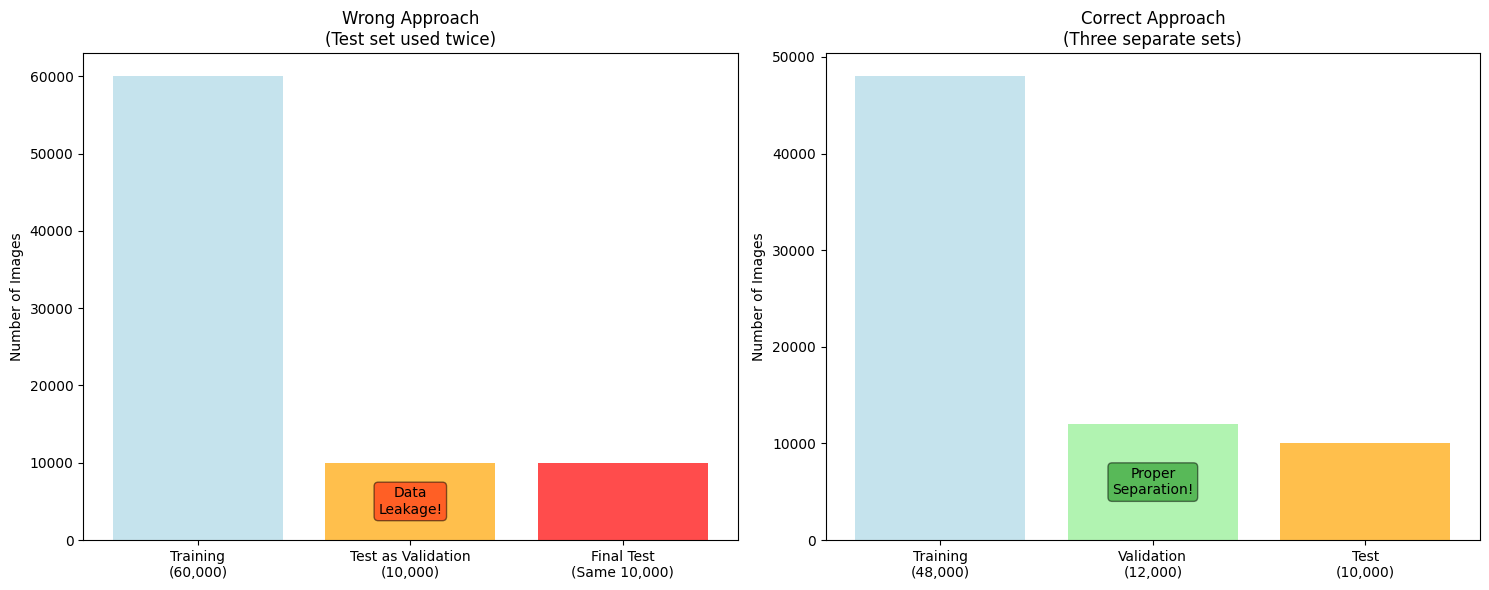


Key Differences:
Wrong approach:
   • Test set (10,000) used for validation during training
   • Same test set used for final evaluation
   • Creates data leakage

Correct approach:
   • Training data split into train (48,000) and validation (12,000)
   • Test set (10,000) never seen during training
   • Unbiased final evaluation


In [21]:
import matplotlib.pyplot as plt

def compare_approaches():
    """
    Visualizes the difference between wrong and correct data splitting approaches.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Wrong approach visualization
    ax1.bar(['Training\n(60,000)', 'Test as Validation\n(10,000)', 'Final Test\n(Same 10,000)'], 
            [60000, 10000, 10000], 
            color=['lightblue', 'orange', 'red'], alpha=0.7)
    ax1.set_title('Wrong Approach\n(Test set used twice)')
    ax1.set_ylabel('Number of Images')
    ax1.text(1, 5000, 'Data\nLeakage!', ha='center', va='center', 
             bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))
    
    # Correct approach visualization
    ax2.bar(['Training\n(48,000)', 'Validation\n(12,000)', 'Test\n(10,000)'], 
            [48000, 12000, 10000], 
            color=['lightblue', 'lightgreen', 'orange'], alpha=0.7)
    ax2.set_title('Correct Approach\n(Three separate sets)')
    ax2.set_ylabel('Number of Images')
    ax2.text(1, 6000, 'Proper\nSeparation!', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='green', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("\nKey Differences:")
    print("Wrong approach:")
    print("   • Test set (10,000) used for validation during training")
    print("   • Same test set used for final evaluation")
    print("   • Creates data leakage")
    print("")
    print("Correct approach:")
    print("   • Training data split into train (48,000) and validation (12,000)")
    print("   • Test set (10,000) never seen during training")
    print("   • Unbiased final evaluation")

# Compare the approaches
compare_approaches()
